In [1]:
# ejecutar esta celda para instalar las librerías necesarias
# %pip install pandas numpy matplotlib scikit-learn

# Predicción de salarios con aprendizaje automático
En este notebook resolvemos un problema de regresión: predecir el salario de un trabajador a partir de variables como el puesto, la experiencia, el nivel educativo, el sector, el tamaño de la empresa o la modalidad de trabajo.

El objetivo no es solo entrenar un modelo, sino comparar varias alternativas, justificar el preprocesado aplicado y analizar qué variables aportan más información a la predicción final.

La estructura del cuaderno sigue estas fases: exploración inicial del dataset, visualización de variables, preprocesamiento, comparación de modelos, optimización del modelo final e interpretabilidad de los resultados.

1. Importacion de librerias 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocesamiento y validacion
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Algoritmos de regresion
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Metricas
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 2. Carga y exploracion inicial del dataset
En esta fase cargamos el dataset original completo y comprobamos su estructura. Aunque al principio habiamos dejado anotado que podria hacer falta imputar valores, la comprobacion muestra que no existen nulos en las variables.

Por eso no aplicamos una limpieza agresiva ni eliminamos filas: mantenemos toda la informacion disponible y documentamos que el dataset no requiere imputacion en su estado actual. Tambien revisamos si existen duplicados para detectar posibles problemas adicionales de calidad.

## 3. Exploracion visual del dataset
Ademas de mirar tipos y nulos, conviene visualizar la distribucion de la variable objetivo y algunas relaciones basicas entre variables. Esto ayuda a detectar sesgos, dispersion y patrones iniciales antes de entrenar modelos.

En particular, observamos la distribucion del salario, los anos de experiencia y dos vistas agregadas que permiten intuir si la modalidad de trabajo o el puesto afectan al salario medio.

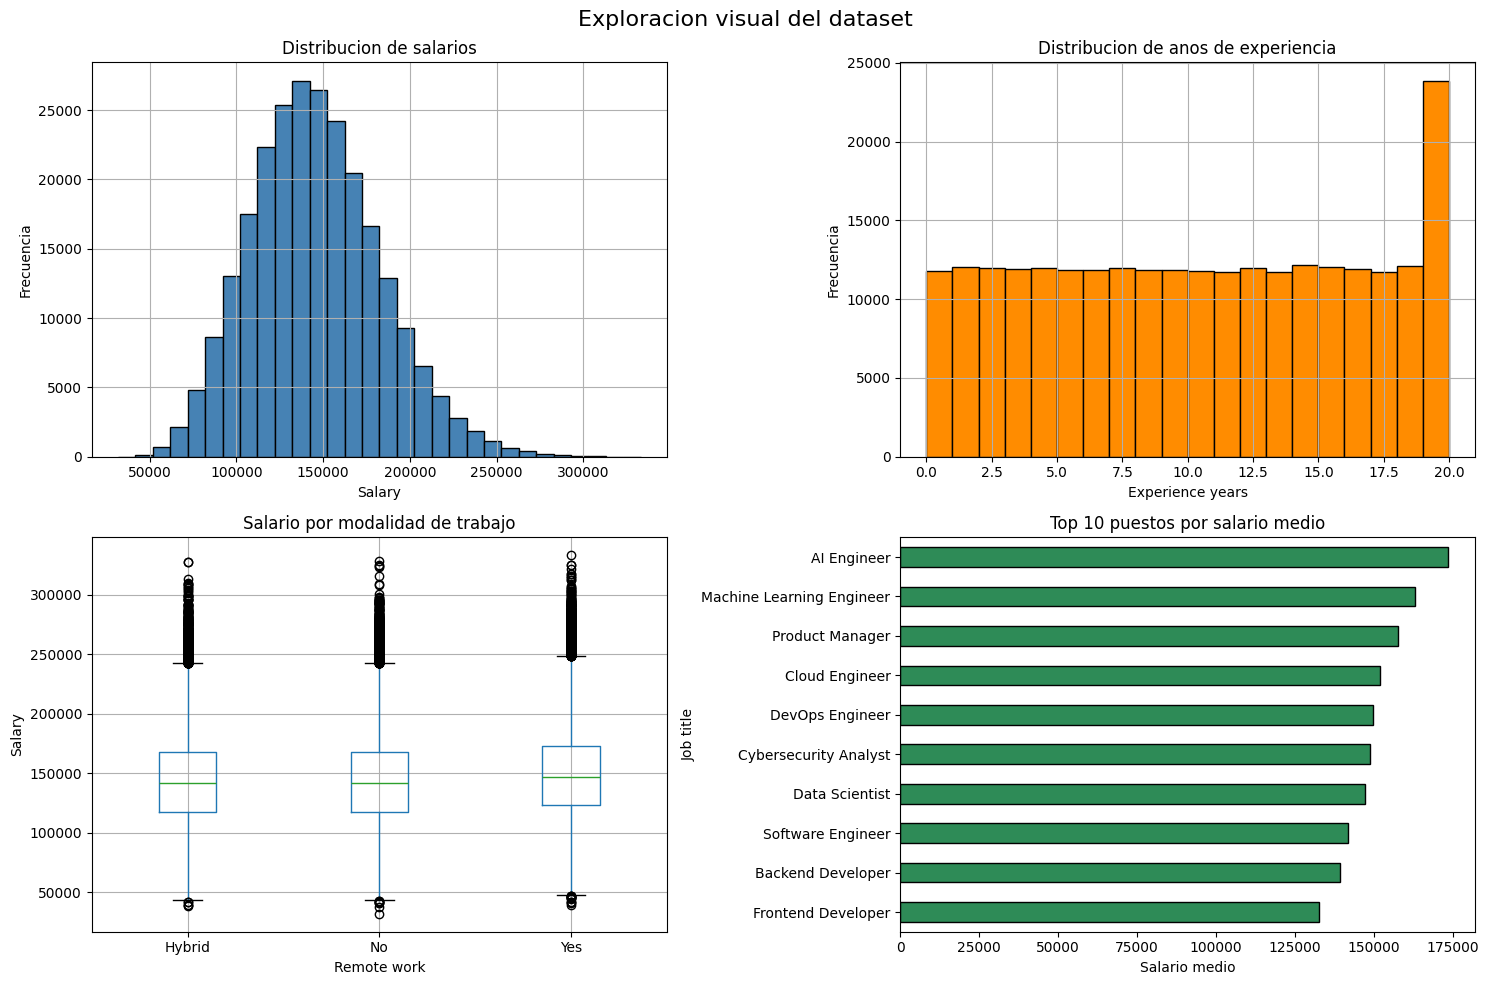

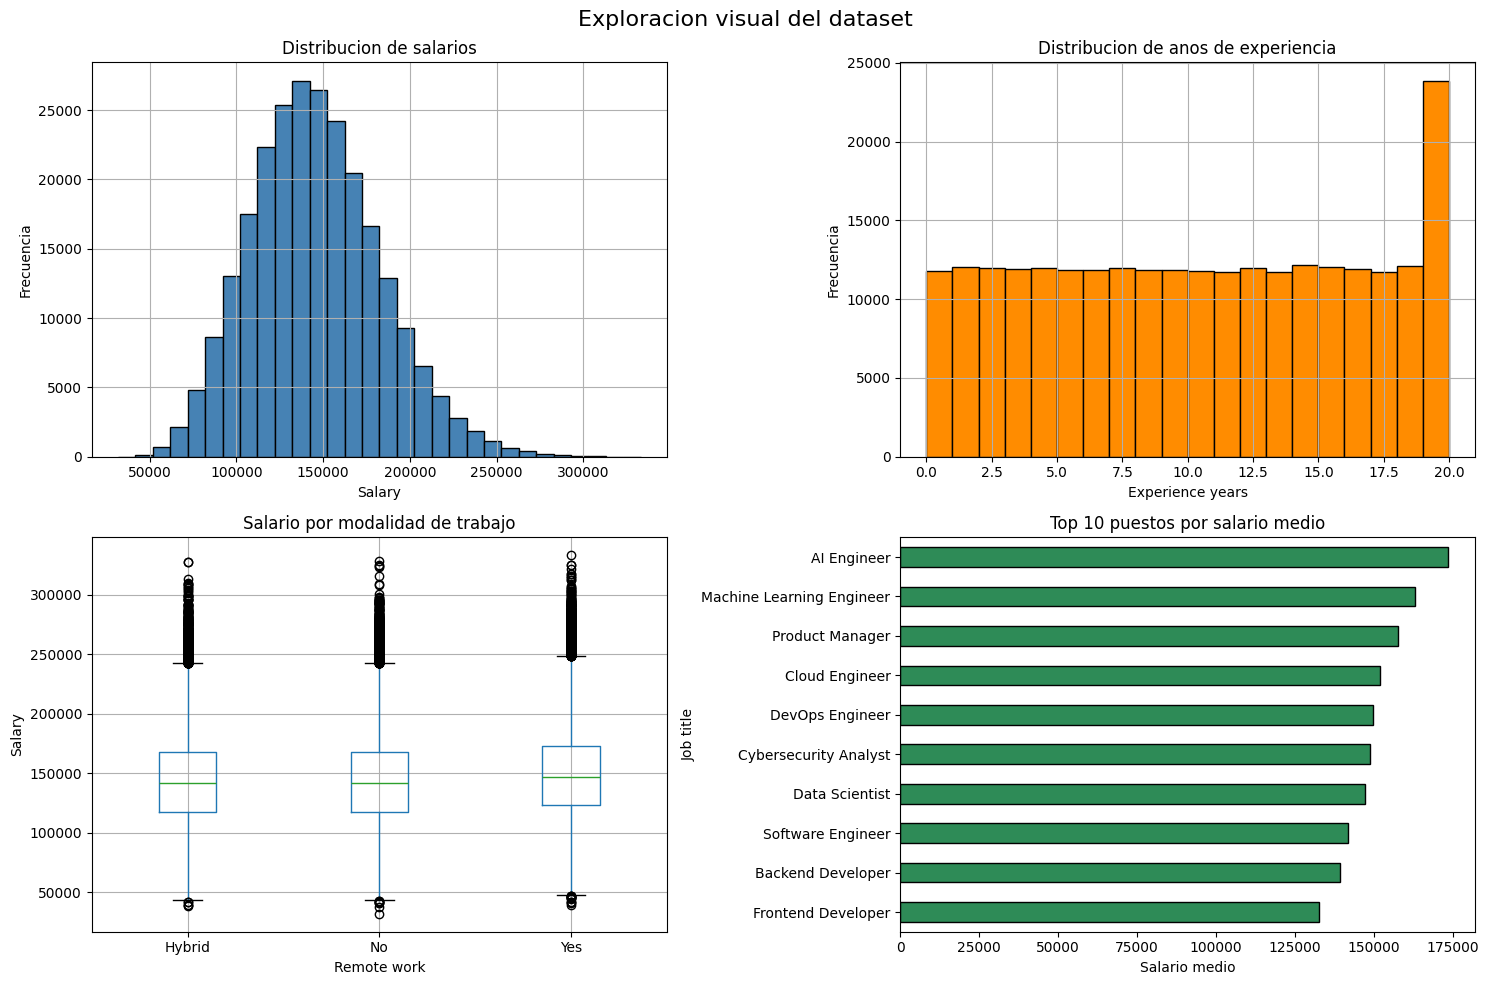

,count,mean,median
remote_work,,,
Yes,82903,149279.59,147153.0
Hybrid,83476,143969.90,141672.0
No,83621,143932.30,141630.0


In [3]:
if 'df' not in globals():
    df = pd.read_csv('job_salary_prediction_dataset.csv')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df['salary'].hist(bins=30, ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribucion de salarios')
axes[0, 0].set_xlabel('Salary')
axes[0, 0].set_ylabel('Frecuencia')

df['experience_years'].hist(bins=20, ax=axes[0, 1], color='darkorange', edgecolor='black')
axes[0, 1].set_title('Distribucion de anos de experiencia')
axes[0, 1].set_xlabel('Experience years')
axes[0, 1].set_ylabel('Frecuencia')

df.boxplot(column='salary', by='remote_work', ax=axes[1, 0])
axes[1, 0].set_title('Salario por modalidad de trabajo')
axes[1, 0].set_xlabel('Remote work')
axes[1, 0].set_ylabel('Salary')

top_roles = df.groupby('job_title')['salary'].mean().sort_values(ascending=False).head(10)
top_roles.sort_values().plot(kind='barh', ax=axes[1, 1], color='seagreen', edgecolor='black')
axes[1, 1].set_title('Top 10 puestos por salario medio')
axes[1, 1].set_xlabel('Salario medio')
axes[1, 1].set_ylabel('Job title')

plt.suptitle('Exploracion visual del dataset', fontsize=16)
plt.tight_layout()
plt.show()

display(
    df.groupby('remote_work')['salary']
    .agg(['count', 'mean', 'median'])
    .sort_values(by='mean', ascending=False)
    .round(2)
)

In [4]:
df = pd.read_csv('job_salary_prediction_dataset.csv')

print('Dimensiones:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum())
print('\nFilas duplicadas:', df.duplicated().sum())
print('\nResumen de la variable objetivo salary:')
print(df['salary'].describe())

df.head()

Dimensiones: (250000, 10)

Tipos de datos:
job_title             str
experience_years    int64
education_level       str
skills_count        int64
industry              str
company_size          str
location              str
remote_work           str
certifications      int64
salary              int64
dtype: object

Valores nulos por columna:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Filas duplicadas: 0

Resumen de la variable objetivo salary:
count    250000.000000
mean     145718.080524
std       37407.952729
min       31867.000000
25%      119358.000000
50%      143453.000000
75%      169492.000000
max      333046.000000
Name: salary, dtype: float64


Dimensiones: (250000, 10)

Tipos de datos:
job_title             str
experience_years    int64
education_level       str
skills_count        int64
industry              str
company_size          str
location              str
remote_work           str
certifications      int64
salary              int64
dtype: object

Valores nulos por columna:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Filas duplicadas: 0

Resumen de la variable objetivo salary:
count    250000.000000
mean     145718.080524
std       37407.952729
min       31867.000000
25%      119358.000000
50%      143453.000000
75%      169492.000000
max      333046.000000
Name: salary, dtype: float64


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## 4. Preprocesamiento y division de datos
El problema es de regresion, por lo que separamos las variables predictoras de la variable objetivo `salary`. A continuacion dividimos el dataset en entrenamiento y prueba para reservar un conjunto final de evaluacion que no participe en el ajuste de los modelos.

Aunque el dataset no presenta nulos, dejamos preparado un pipeline con imputacion numerica y categorica para que el flujo sea robusto si en futuras versiones del dataset aparecieran valores ausentes. Las variables numericas se estandarizan y las categoricas se transforman con one-hot encoding.

In [5]:
# Variables predictoras y variable objetivo
X = df.drop('salary', axis=1)
y = df['salary']

# Columnas numericas y categoricas
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=20))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Usamos 2 folds para reducir tiempos de computo manteniendo validacion cruzada
cv_strategy = KFold(n_splits=2, shuffle=True, random_state=42)

print(f'Muestras para entrenar: {X_train.shape[0]}')
print(f'Muestras para validar: {X_test.shape[0]}')
print(f'Numero de variables numericas: {len(num_cols)}')
print(f'Numero de variables categoricas: {len(cat_cols)}')

Muestras para entrenar: 200000
Muestras para validar: 50000
Numero de variables numericas: 3
Numero de variables categoricas: 6


## 5. Comprobacion del preprocesado
Antes de comparar modelos conviene verificar que el transformador deja los datos en un formato util para los algoritmos. En esta comprobacion ajustamos el preprocesador sobre el conjunto de entrenamiento y observamos la dimensionalidad final tras escalar variables numericas y expandir variables categoricas con one-hot encoding.

Esto refuerza la explicacion metodologica del notebook y deja claro que el flujo transforma correctamente todas las columnas a formato numerico.

In [6]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print('Forma del conjunto de entrenamiento tras el preprocesado:', X_train_transformed.shape)
print('Forma del conjunto de prueba tras el preprocesado:', X_test_transformed.shape)
print('Numero total de variables generadas:', len(preprocessor.get_feature_names_out()))

feature_names = preprocessor.get_feature_names_out()
print('\nPrimeras 15 variables transformadas:')
print(feature_names[:15])

Forma del conjunto de entrenamiento tras el preprocesado: (200000, 48)
Forma del conjunto de prueba tras el preprocesado: (50000, 48)
Numero total de variables generadas: 48

Primeras 15 variables transformadas:
['num__experience_years' 'num__skills_count' 'num__certifications'
 'cat__job_title_AI Engineer' 'cat__job_title_Backend Developer'
 'cat__job_title_Business Analyst' 'cat__job_title_Cloud Engineer'
 'cat__job_title_Cybersecurity Analyst' 'cat__job_title_Data Analyst'
 'cat__job_title_Data Scientist' 'cat__job_title_DevOps Engineer'
 'cat__job_title_Frontend Developer'
 'cat__job_title_Machine Learning Engineer'
 'cat__job_title_Product Manager' 'cat__job_title_Software Engineer']


## 6. Entrenamiento, comparacion y validacion de modelos
En esta fase entrenamos varios modelos de regresion sobre el mismo pipeline de preprocesado. Para mantener la comparacion robusta pero reducir tiempos de ejecucion, usamos validacion cruzada de 2 particiones sobre entrenamiento y una evaluacion final sobre el conjunto de prueba separado.

### Sobre `n_jobs`: diferencia entre `-1` y `1`
- `n_jobs=-1`: usa todos los nucleos de la CPU para paralelizar una tarea.
- `n_jobs=1`: ejecuta en un solo nucleo.

En este notebook usamos ambas configuraciones segun el caso:
- En modelos como Random Forest y KNN usamos `n_jobs=-1` para acelerar el propio algoritmo.
- En `cross_validate` usamos `n_jobs=1` para evitar paralelismo anidado (multiples procesos por fuera y por dentro a la vez), que en datasets grandes puede empeorar tiempos por sobrecarga.
- En `RandomizedSearchCV` usamos `n_jobs=-1` porque el propio modelo interno ya gestiona sus recursos y la busqueda se beneficia del paralelismo externo.

### Metricas elegidas y por que
- `R2` (`CV R2 medio` y `Test R2`): mide la proporcion de variabilidad del salario explicada por el modelo. Cuanto mas cerca de 1, mejor ajuste.
- `MSE` (`CV MSE medio` y `Test MSE`): error cuadratico medio. Penaliza mas los errores grandes, por eso es util cuando importa evitar predicciones muy alejadas.
- `CV R2 std`: desviacion tipica del R2 entre folds; indica estabilidad del modelo. Valores bajos implican comportamiento mas consistente.

Usamos a la vez `R2` y `MSE` porque son complementarias: una ofrece interpretacion relativa del ajuste y la otra una medida absoluta del error en unidades cuadradas del salario.

In [7]:
modelos = {
    '1. Regresion Lineal': LinearRegression(),
    '2. Ridge': Ridge(alpha=1.0),
    '3. K-Vecinos (KNN)': KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    '4. Random Forest': RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1),
    '5. Gradient Boosting': GradientBoostingRegressor(n_estimators=80, random_state=42)
}

resultados = []

for nombre, algoritmo in modelos.items():
    print(f'Entrenando {nombre}...')

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', algoritmo)
    ])

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring={'r2': 'r2', 'mse': 'neg_mean_squared_error'},
        # Aqui dejamos n_jobs=1 para evitar paralelismo anidado con modelos que ya usan n_jobs=-1.
        n_jobs=1
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mse_test = mean_squared_error(y_test, y_pred)
    r2_test = r2_score(y_test, y_pred)

    resultados.append({
        'Modelo': nombre,
        'CV R2 medio': cv_results['test_r2'].mean(),
        'CV R2 std': cv_results['test_r2'].std(),
        # sklearn devuelve MSE negativa en scoring para mantener la convencion de "mayor es mejor".
        'CV MSE medio': -cv_results['test_mse'].mean(),
        'Test R2': r2_test,
        'Test MSE': mse_test
    })

    print(
        f" -> CV R2 medio: {cv_results['test_r2'].mean():.4f} "
        f"(+/- {cv_results['test_r2'].std():.4f}) | "
        f"Test R2: {r2_test:.4f} | Test MSE: {mse_test:,.2f}\n"
    )

resultados_df = pd.DataFrame(resultados).sort_values(by='Test R2', ascending=False).reset_index(drop=True)
display(resultados_df)

print(f"Mejor modelo base segun Test R2: {resultados_df.loc[0, 'Modelo']}")

Entrenando 1. Regresion Lineal...
 -> CV R2 medio: 0.9633 (+/- 0.0002) | Test R2: 0.9635 | Test MSE: 50,773,076.89

Entrenando 2. Ridge...
 -> CV R2 medio: 0.9633 (+/- 0.0002) | Test R2: 0.9635 | Test MSE: 50,772,652.46

Entrenando 3. K-Vecinos (KNN)...
 -> CV R2 medio: 0.8551 (+/- 0.0005) | Test R2: 0.8734 | Test MSE: 175,895,299.45

Entrenando 4. Random Forest...
 -> CV R2 medio: 0.9319 (+/- 0.0001) | Test R2: 0.9309 | Test MSE: 96,028,893.98

Entrenando 5. Gradient Boosting...
 -> CV R2 medio: 0.9283 (+/- 0.0004) | Test R2: 0.9283 | Test MSE: 99,655,083.84



Entrenando 1. Regresion Lineal...
 -> CV R2 medio: 0.9633 (+/- 0.0002) | Test R2: 0.9635 | Test MSE: 50,773,076.89

Entrenando 2. Ridge...
 -> CV R2 medio: 0.9633 (+/- 0.0002) | Test R2: 0.9635 | Test MSE: 50,772,652.46

Entrenando 3. K-Vecinos (KNN)...
 -> CV R2 medio: 0.8551 (+/- 0.0005) | Test R2: 0.8734 | Test MSE: 175,895,299.45

Entrenando 4. Random Forest...
 -> CV R2 medio: 0.9319 (+/- 0.0001) | Test R2: 0.9309 | Test MSE: 96,028,893.98

Entrenando 5. Gradient Boosting...
 -> CV R2 medio: 0.9283 (+/- 0.0004) | Test R2: 0.9283 | Test MSE: 99,655,083.84



,Modelo,CV R2 medio,CV R2 std,CV MSE medio,Test R2,Test MSE
0,2. Ridge,0.963342,0.000170,5.138483e+07,0.963469,5.077265e+07
1,1. Regresion Lineal,0.963342,0.000170,5.138472e+07,0.963469,5.077308e+07
2,4. Random Forest,0.931919,0.000113,9.543038e+07,0.930908,9.602889e+07
3,5. Gradient Boosting,0.928339,0.000417,1.004480e+08,0.928299,9.965508e+07
4,3. K-Vecinos (KNN),0.855126,0.000450,2.030731e+08,0.873444,1.758953e+08


Mejor modelo base segun Test R2: 2. Ridge


## 7. Optimizacion de hiperparametros
Una vez comparados los modelos base, afinamos un Random Forest porque suele ofrecer buen equilibrio entre capacidad predictiva, robustez ante relaciones no lineales e interpretabilidad mediante importancias de variables.

Para evitar tiempos excesivos de entrenamiento, reducimos el espacio de busqueda y el numero de iteraciones aleatorias. Esta configuracion esta pensada para una practica docente, priorizando buen rendimiento con coste computacional razonable.

In [ ]:
param_distributions = {
    'model__n_estimators': [80, 120],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [5, 10]
}

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_distributions,
    n_iter=2,
    cv=cv_strategy,
    scoring='r2',
    random_state=42,
    n_jobs=-1  # Usamos todos los cores disponibles para acelerar la busqueda.
)

print('Iniciando optimizacion de hiperparametros para Random Forest...')
random_search.fit(X_train, y_train)

mejor_rf = random_search.best_estimator_
y_pred_rf = mejor_rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Mejores hiperparametros encontrados:\n{random_search.best_params_}')
print(f'Mejor R2 medio en validacion cruzada: {random_search.best_score_:.4f}')
print(f'R2 en test del modelo optimizado: {r2_rf:.4f}')
print(f'MSE en test del modelo optimizado: {mse_rf:,.2f}')

Iniciando optimizacion de hiperparametros para Random Forest...
Fitting 2 folds for each of 2 candidates, totalling 4 fits
Mejores hiperparametros encontrados:
{'model__n_estimators': 120, 'model__min_samples_split': 5, 'model__max_depth': 20}
Mejor R2 medio en validacion cruzada: 0.9619
R2 en test del modelo optimizado: 0.9647
MSE en test del modelo optimizado: 49,001,810.70


## 8. Interpretabilidad del modelo final
Aqui analizamos que variables influyen mas en el Random Forest optimizado. Esto no significa causalidad, pero si ofrece una pista util sobre que factores han resultado mas informativos para la prediccion del salario.

Es importante distinguir este concepto de la interoperabilidad: la interoperabilidad se refiere a la capacidad de distintos sistemas para trabajar juntos; aqui lo que estamos estudiando es la interpretabilidad del modelo.

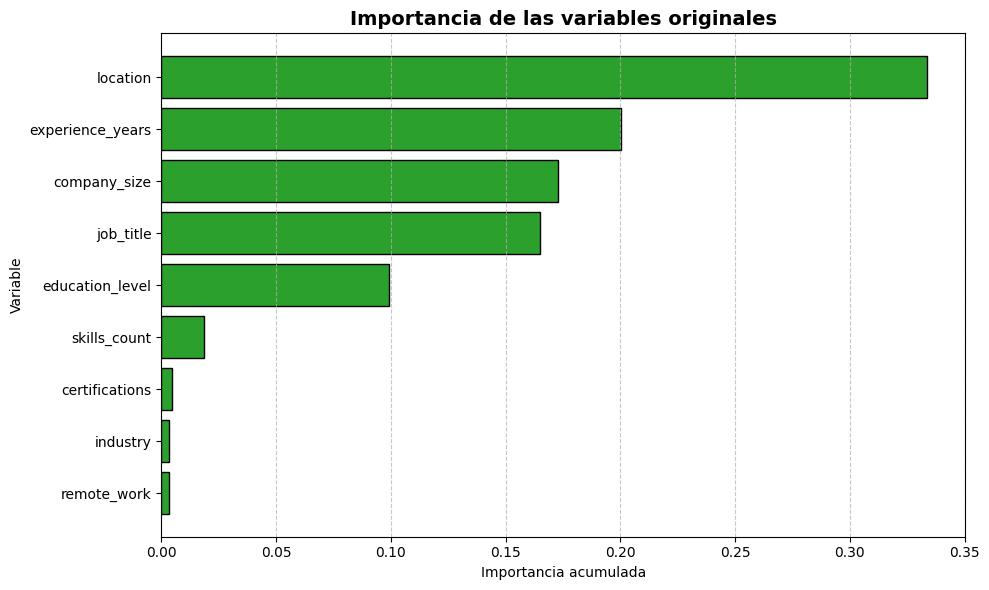

,Variable,Importancia
0,location,0.333479
1,experience_years,0.200047
2,company_size,0.172710
3,job_title,0.165042
4,education_level,0.099072
5,skills_count,0.018381
6,certifications,0.004729
7,industry,0.003445
8,remote_work,0.003095



Variables mas influyentes en el modelo final:
 - location: 33.35% de importancia acumulada
 - experience_years: 20.00% de importancia acumulada
 - company_size: 17.27% de importancia acumulada
 - job_title: 16.50% de importancia acumulada
 - education_level: 9.91% de importancia acumulada


In [9]:
# Nombres de las variables tras el preprocesado
nombres_variables = mejor_rf.named_steps['preprocessor'].get_feature_names_out()

# Importancia de cada variable generada por el modelo
importancias = mejor_rf.named_steps['model'].feature_importances_
importancias_absolutas = {col: 0.0 for col in X.columns}

for nombre_completo, importancia in zip(nombres_variables, importancias):
    for col_original in X.columns:
        if f'num__{col_original}' == nombre_completo or nombre_completo.startswith(f'cat__{col_original}_'):
            importancias_absolutas[col_original] += importancia
            break

df_importancias = pd.DataFrame(
    list(importancias_absolutas.items()),
    columns=['Variable', 'Importancia']
).sort_values(by='Importancia', ascending=False).reset_index(drop=True)

top_importancias = df_importancias.head(10).sort_values(by='Importancia')

plt.figure(figsize=(10, 6))
plt.barh(top_importancias['Variable'], top_importancias['Importancia'], color='#2ca02c', edgecolor='black')
plt.title('Importancia de las variables originales', fontsize=14, fontweight='bold')
plt.xlabel('Importancia acumulada')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(df_importancias.head(10))

print('\nVariables mas influyentes en el modelo final:')
for _, fila in df_importancias.head(5).iterrows():
    print(f" - {fila['Variable']}: {fila['Importancia'] * 100:.2f}% de importancia acumulada")

## 9. Conclusiones

### Resumen del problema
Se ha resuelto un problema de **regresion** consistente en predecir el salario de un trabajador a partir de 9 variables (puesto, experiencia, nivel educativo, numero de habilidades, sector, tamano de empresa, ubicacion, modalidad de trabajo y certificaciones). El dataset contiene 250.000 registros sin valores nulos ni duplicados, lo que ha permitido trabajar directamente sobre los datos originales sin necesidad de imputacion.

### Comparacion de modelos y eleccion final
Se han comparado cinco algoritmos de regresion con validacion cruzada y evaluacion sobre un conjunto de test independiente (20% de los datos):

| Modelo | Test R2 |
|--------|---------|
| Ridge / Regresion Lineal | 0.9635 |
| Random Forest (base) | 0.9309 |
| Gradient Boosting | 0.9283 |
| K-Vecinos (KNN) | 0.8734 |

Tras optimizar hiperparametros del Random Forest mediante `RandomizedSearchCV`, el modelo final alcanza un **R2 de 0.9647** con los parametros `n_estimators=120`, `max_depth=20` y `min_samples_split=5`. Este valor supera ligeramente al modelo lineal base.

### Por que Random Forest y no Regresion Lineal
Aunque Ridge y Regresion Lineal obtienen un R2 practicamente identico al Random Forest optimizado, elegimos Random Forest como modelo final por las siguientes razones:
1. **Interpretabilidad mediante importancias de variables**: permite identificar que factores pesan mas en la prediccion, algo que un modelo lineal con one-hot encoding no ofrece de forma tan directa.
2. **Robustez ante relaciones no lineales**: si el dataset creciera o cambiara su estructura, un modelo basado en arboles se adaptara mejor que un modelo lineal.
3. **Capacidad de mejora**: con mas recursos computacionales o un espacio de busqueda mayor, Random Forest tiene mas margen de optimizacion.

### Variables mas influyentes
El analisis de importancias del modelo final revela:
- **location** (33.3%): la ubicacion geografica es el factor que mas peso tiene en la prediccion del salario.
- **experience_years** (20.0%): los anos de experiencia son el segundo predictor mas relevante.
- **company_size** (17.3%): el tamano de la empresa influye significativamente.
- **job_title** (16.5%): el puesto de trabajo aporta informacion considerable.
- **education_level** (9.9%): el nivel educativo tiene un peso menor pero relevante.

### Metodologia aplicada
- Preprocesado robusto con pipeline (estandarizacion numerica + one-hot encoding categorico con agrupacion de categorias infrecuentes).
- Validacion cruzada de 2 folds para comparar modelos de forma objetiva.
- Evaluacion final sobre conjunto de test no visto durante el entrenamiento.
- Optimizacion de hiperparametros con busqueda aleatoria.
- Analisis de interpretabilidad del modelo ganador.

### Limitaciones y posibles mejoras
- El R2 cercano a 0.96 indica que el dataset puede tener una relacion bastante determinista entre variables y salario (posible dato sintetico), lo que limita la generalizacion de conclusiones a un escenario real.
- Con mas tiempo de computo se podria ampliar el espacio de busqueda de hiperparametros o probar Gradient Boosting optimizado.
- No se ha explorado ingenieria de features adicional (interacciones entre variables).